In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import pickle

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
digits = load_digits()

df = pd.DataFrame(digits.data)

df['target'] = digits.target

print(df.head())


     0    1    2     3     4     5    6    7    8    9  ...   55   56   57  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  0.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    58    59    60    61   62   63  target  
0  6.0  13.0  10.0   0.0  0.0  0.0       0  
1  0.0  11.0  16.0  10.0  0.0  0.0       1  
2  0.0   3.0  11.0  16.0  9.0  0.0       2  
3  7.0  13.0  13.0   9.0  0.0  0.0       3  
4  0.0   2.0  16.0   4.0  0.0  0.0       4  

[5 rows x 65 columns]


In [3]:
X = df.drop('target', axis='columns')
y = df.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Size:", len(X_train))
print("Testing Data Size:", len(X_test))

Training Data Size: 1437
Testing Data Size: 360


In [5]:
scores = []

for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)

    scores.append(score)

    print(f"K = {k} ---> Accuracy = {score}")

K = 1 ---> Accuracy = 0.9777777777777777
K = 2 ---> Accuracy = 0.9805555555555555
K = 3 ---> Accuracy = 0.9833333333333333
K = 4 ---> Accuracy = 0.9805555555555555
K = 5 ---> Accuracy = 0.9861111111111112
K = 6 ---> Accuracy = 0.9888888888888889
K = 7 ---> Accuracy = 0.9888888888888889
K = 8 ---> Accuracy = 0.9861111111111112
K = 9 ---> Accuracy = 0.9805555555555555
K = 10 ---> Accuracy = 0.9833333333333333
K = 11 ---> Accuracy = 0.9833333333333333
K = 12 ---> Accuracy = 0.9777777777777777
K = 13 ---> Accuracy = 0.9777777777777777
K = 14 ---> Accuracy = 0.9805555555555555
K = 15 ---> Accuracy = 0.9777777777777777


In [6]:
best_k = scores.index(max(scores)) + 1

print("\nBest K Value:", best_k)

# Train final model with best K
model = KNeighborsClassifier(n_neighbors=best_k)

model.fit(X_train, y_train)


Best K Value: 6


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [7]:
accuracy = model.score(X_test, y_test)

print("\nFinal Accuracy:", accuracy)


Final Accuracy: 0.9888888888888889


In [8]:
prediction = model.predict([X_test.iloc[0]])

print("\nPredicted Digit:", prediction[0])
print("Actual Digit:", y_test.iloc[0])




Predicted Digit: 6
Actual Digit: 6


In [9]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  0  1  1  0  0  0 38]]


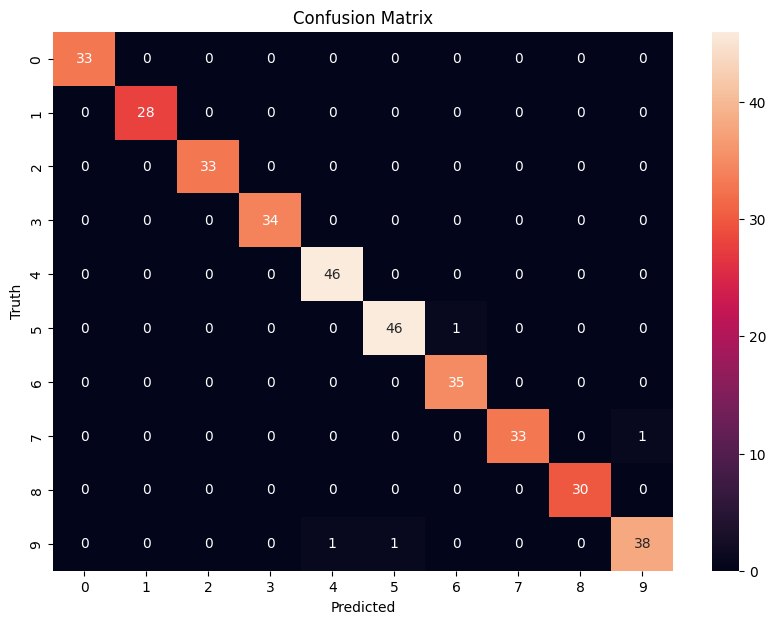

In [10]:
plt.figure(figsize=(10,7))

sn.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Truth')

plt.title('Confusion Matrix')

plt.show()


In [11]:
report = classification_report(y_test, y_pred)

print("\nClassification Report:\n")
print(report)



Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



In [12]:
with open("digits_knn_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel saved successfully as 'digits_knn_model.pkl'")


Model saved successfully as 'digits_knn_model.pkl'


In [13]:
with open("digits_knn_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully")


Model loaded successfully


In [14]:
loaded_prediction = loaded_model.predict([X_test.iloc[1]])

print("\nPrediction using Loaded Model:", loaded_prediction[0])
print("Actual Value:", y_test.iloc[1])


Prediction using Loaded Model: 9
Actual Value: 9
